## UrbanCart
---
## Business Problem

As the freelance ML engineer brought in by UrbanCart, my second engagement was with the retention team lead. She raised a concern that customers were quietly dropping off with no clear warning, and by the time it showed up in the monthly reports, they were already gone and past the point of any real intervention. She handed me a historical dataset of about 20,000 customers (months active, average order value, recent order frequency, days since their last order, and support tickets filed), along with a flag showing which customers had actually churned (only around 8% of them). 

My task was to build and compare at least two suitable models to predict which customers were at risk of churning, evaluate them properly given how imbalanced the data was (since a model could look "accurate" while catching zero at-risk customers), and hand back a clear, evidence-backed recommendation the retention team could use to flag high-risk customers early enough to actually act, instead of finding out only after they were already gone.

In [591]:
#import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, classification_report, 
fbeta_score, average_precision_score, precision_recall_curve, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.pipeline import make_pipeline as make_imb_pipeline
#from imblearn.over_sampling import SMOTE

In [4]:
raw_data = pd.read_csv(r"C:\Users\HP\Desktop\TeSA\TeSA AI Specialization Assignment III\milestone-2-customer-churn.csv")
raw_data.head()

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,DaysSinceLastOrder,SupportTicketsFiled,Churned
0,7,34.12,7,8,2,0
1,45,23.38,3,57,1,0
2,24,94.56,7,37,1,0
3,39,46.34,7,0,0,0
4,3,39.04,3,41,2,0


In [6]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MonthsActive          20000 non-null  int64  
 1   AvgOrderValue         20000 non-null  float64
 2   NumOrdersLastQuarter  20000 non-null  int64  
 3   DaysSinceLastOrder    20000 non-null  int64  
 4   SupportTicketsFiled   20000 non-null  int64  
 5   Churned               20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [8]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
MonthsActive,20000.0,30.278700,17.367948,1.00,15.00,30.00,45.000,60.00
AvgOrderValue,20000.0,59.194555,24.713562,11.85,41.62,54.81,71.605,402.35
NumOrdersLastQuarter,20000.0,5.012900,1.997181,1.00,4.00,5.00,6.000,14.00
DaysSinceLastOrder,20000.0,19.731550,19.585989,0.00,6.00,14.00,28.000,229.00
SupportTicketsFiled,20000.0,0.495350,0.699788,0.00,0.00,0.00,1.000,5.00
Churned,20000.0,0.078350,0.268728,0.00,0.00,0.00,0.000,1.00


In [10]:
raw_data.duplicated().sum()

0

In [13]:
raw_data.columns

Index(['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter',
       'DaysSinceLastOrder', 'SupportTicketsFiled', 'Churned'],
      dtype='str')

## Exploratory Data Analysis

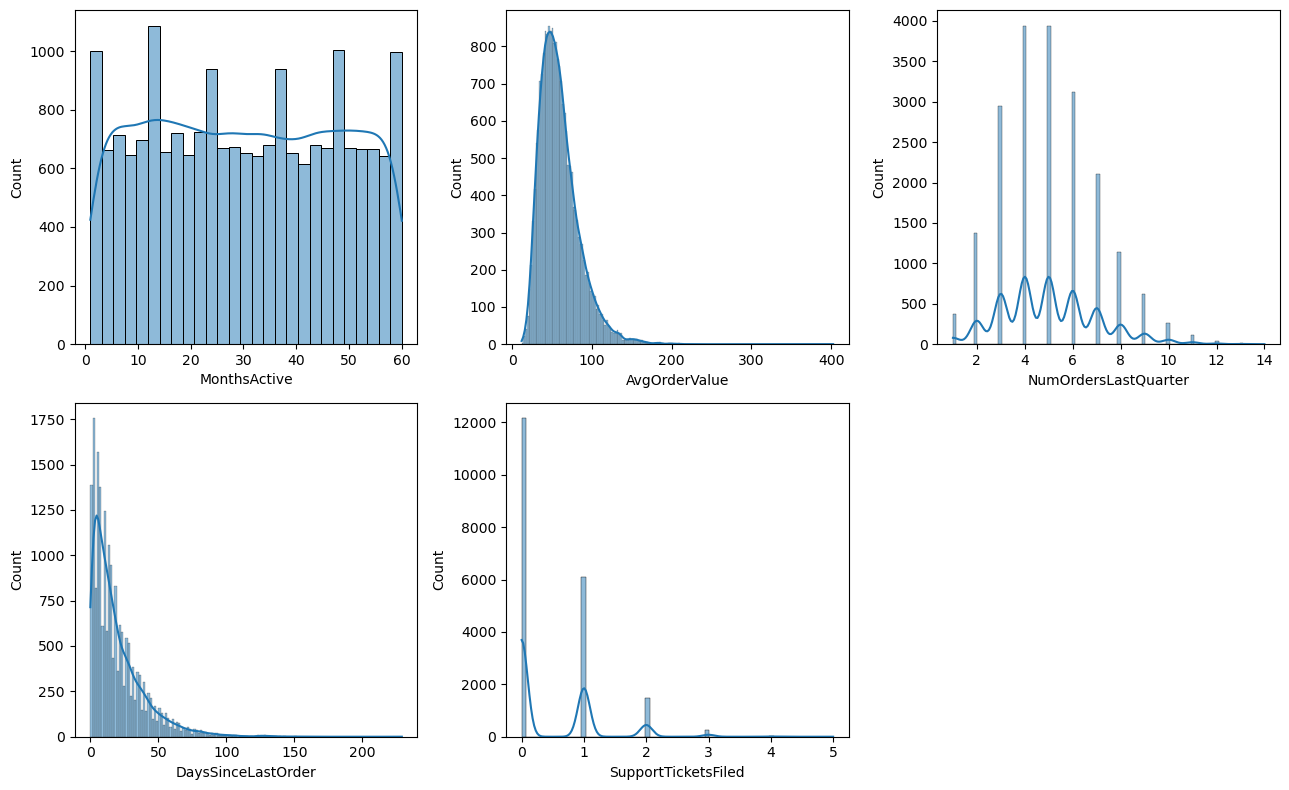

In [15]:
# Visalize numerical features distribution

fig, axes = plt.subplots(2,3,figsize=(13,8))

sns.histplot(raw_data["MonthsActive"],kde=True,ax=axes[0,0])
axes[0,0].set_xlabel("MonthsActive")

sns.histplot(raw_data["AvgOrderValue"],kde=True,ax=axes[0,1])
axes[0,1].set_xlabel("AvgOrderValue")

sns.histplot(raw_data["NumOrdersLastQuarter"],kde=True,ax=axes[0,2])
axes[0,2].set_xlabel("NumOrdersLastQuarter")

sns.histplot(raw_data["DaysSinceLastOrder"],kde=True,ax=axes[1,0])
axes[1,0].set_xlabel("DaysSinceLastOrder")

sns.histplot(raw_data["SupportTicketsFiled"],kde=True,ax=axes[1,1])
axes[1,1].set_xlabel("SupportTicketsFiled")

axes[1,2].axis("off")

plt.tight_layout()
plt.show()

**Insight**: AvgOrderValue and DaysSinceLastOrder distribution are skewed to the right. This means the features contain outliers and needs to be investigated

In [18]:
raw_data["Churned"].value_counts()

Churned
0    18433
1     1567
Name: count, dtype: int64

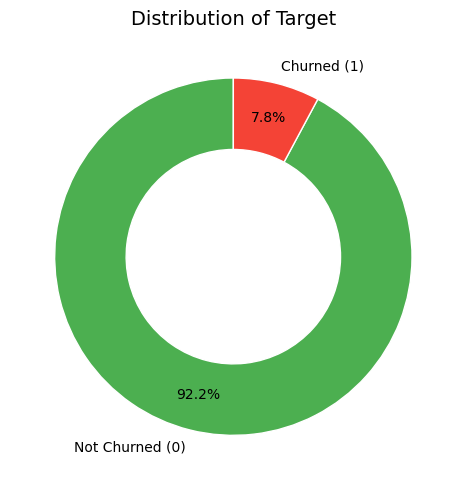

In [42]:
target_counts = raw_data["Churned"].value_counts()
colors = {0: "#4CAF50", 1: "#F44336"}
plot_colors = [colors[idx] for idx in target_counts.index]

#Plot the donut chart
plt.figure(figsize=(6, 5))
plt.pie(target_counts, labels=[f"Not Churned ({target_counts.index[0]})" if idx == 0 else f"Churned ({target_counts.index[1]})" for idx in target_counts.index], 
        autopct='%1.1f%%', startangle=90, colors=plot_colors,pctdistance=0.80,  # Positions the percentages inside the slices
        wedgeprops=dict(width=0.4, edgecolor='w')  # width=0.4 creates the donut hole
)

plt.title("Distribution of Target", fontsize=14)
plt.tight_layout()
plt.show()

**Insight**: The target class is imbalanced. This means that the number of customers that churned the business is far less than the loyal customers. This important information determines what approach to use and how the model will be evaluated

#### Bi-Variate Analysis

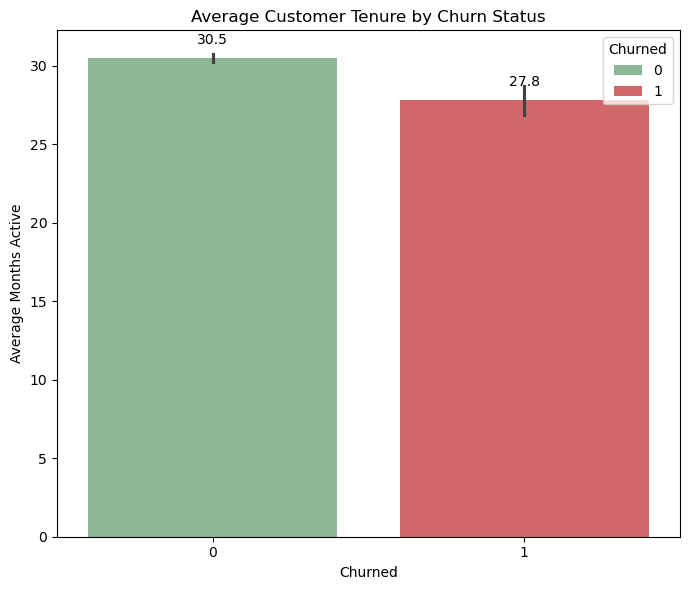

In [52]:
# How long has each category of customers have been with the business?
different_colors = {0: "#86bf91", 1: "#e15759"}

plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="MonthsActive", hue="Churned", data=raw_data, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average Months Active")
plt.title("Average Customer Tenure by Churn Status")
plt.tight_layout()
plt.show()

**Insight**: On average, there is no significant difference in the duration each category of customers has been with the company

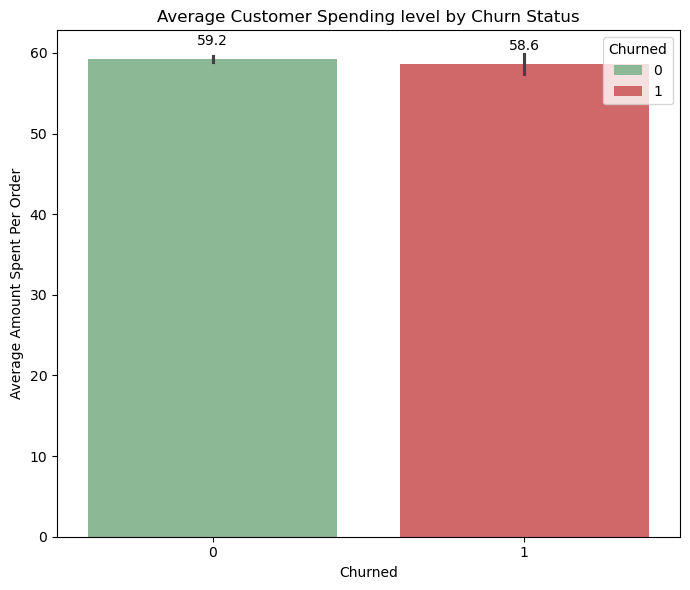

In [57]:
# What is the average spending level in each customer category?
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="AvgOrderValue", hue="Churned", data=raw_data, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average Amount Spent Per Order")
plt.title("Average Customer Spending level by Churn Status")
plt.tight_layout()
plt.show()

**Insight**: There is almost no difference in how much each category of customers spends per order

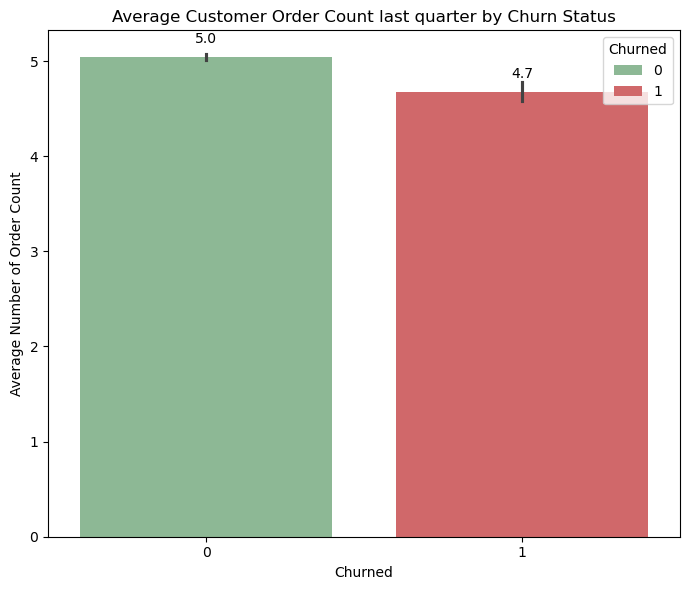

In [66]:
# What is the average order count in the last quarter in each customer category?
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="NumOrdersLastQuarter", hue="Churned", data=raw_data, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average Number of Order Count")
plt.title("Average Customer Order Count last quarter by Churn Status")
plt.tight_layout()
plt.show()

**Insight**: On average, the number of orders in the last quarter is almost the same in each customer category

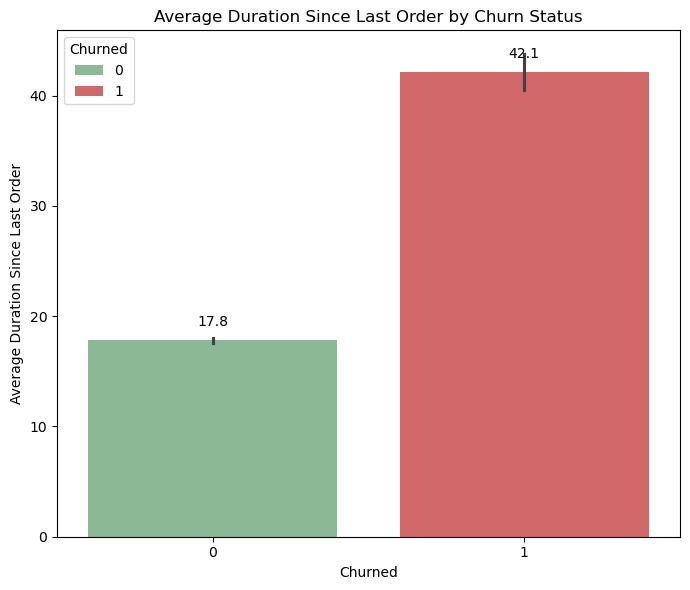

In [70]:
# On average, how long has it been since customers in each category made their last order
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="DaysSinceLastOrder", hue="Churned", data=raw_data, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average Duration Since Last Order")
plt.title("Average Duration Since Last Order by Churn Status")
plt.tight_layout()
plt.show()

**Insight**: On average, customers who eventually churned the business tend to go quiet longer after their last order. Indeed there is a significant difference. This feature will be important in the predictive analysis

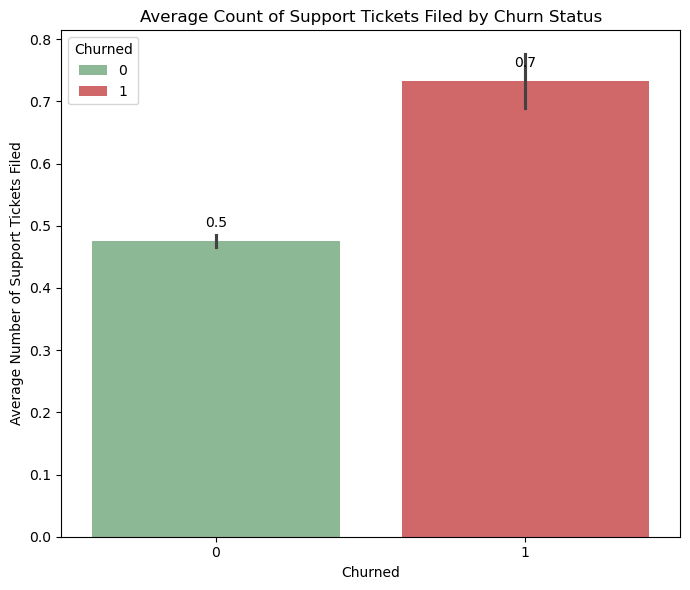

In [73]:
# The SupportTicketsFiled feature could measure the level of dissatisfaction/friction felt by the customer towards the business
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="SupportTicketsFiled", hue="Churned", data=raw_data, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average Number of Support Tickets Filed")
plt.title("Average Count of Support Tickets Filed by Churn Status")
plt.tight_layout()
plt.show()

**Insight**: Only one support ticket is filed on average in each customer category. This feature may be important

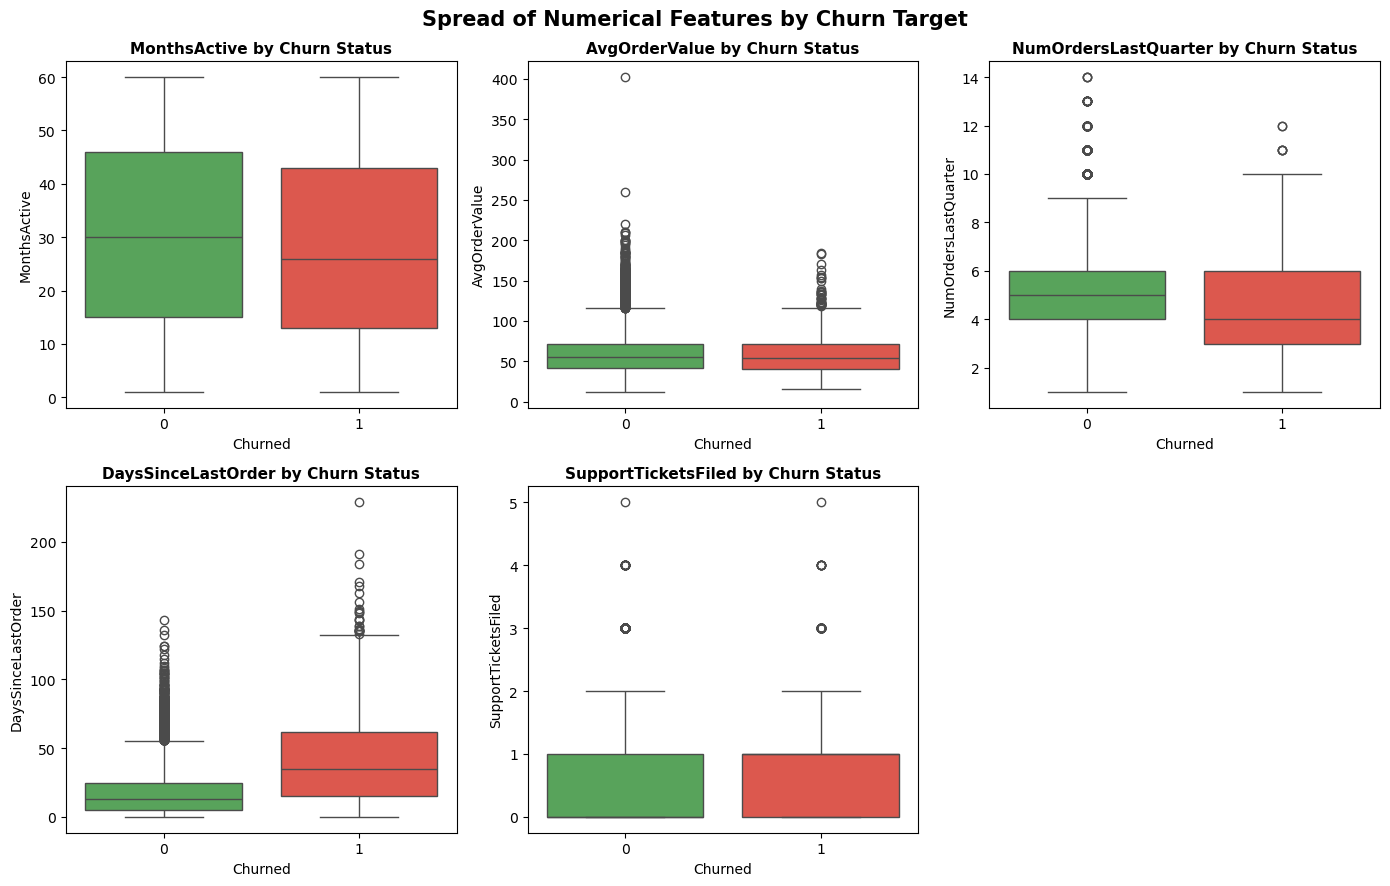

In [80]:
# Define features and color palette for consistency
features = ['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter', 'DaysSinceLastOrder', 'SupportTicketsFiled']
colors = {0: "#4CAF50", 1: "#F44336"}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Flatten axes array for easier, programmable indexing
axes = axes.flatten()

# Loop through features and generate a box plot for each
for i, col in enumerate(features):
    sns.boxplot(data=raw_data, x="Churned", y=col, hue="Churned", palette=colors, ax=axes[i], legend=False)
    axes[i].set_title(f"{col} by Churn Status", fontsize=11, fontweight='bold')
    #axes[i].set_xlabel("Churned (0 = No, 1 = Yes)")
    axes[i].set_ylabel(col)

axes[5].axis("off")

plt.suptitle("Spread of Numerical Features by Churn Target", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

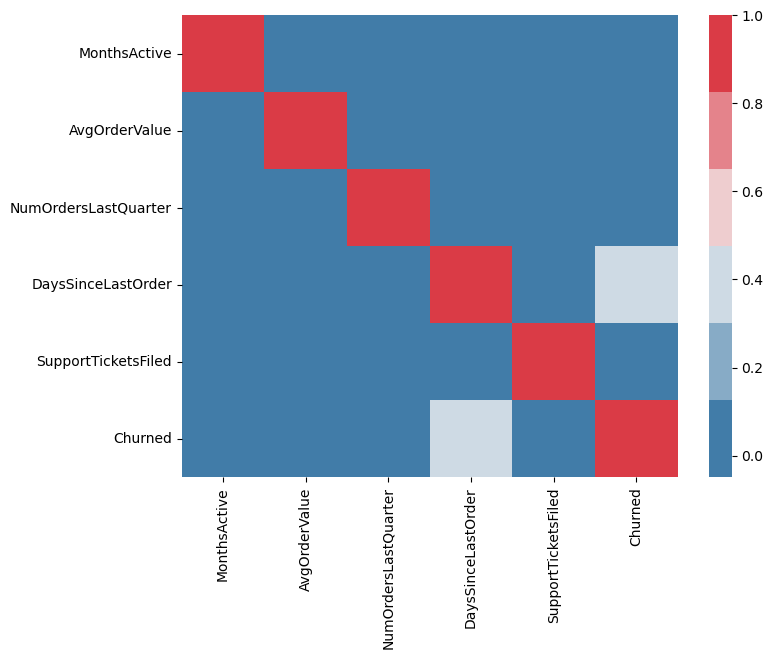

In [92]:
#correlation analysis
plt.figure(figsize=(8,6))
sns.heatmap(data=raw_data.corr(),annot=False, cbar=True, cmap=sns.diverging_palette(240,10))
plt.show()

### Key Insights
------------------------------------------------------------------
- There is a severe class imbalance in the data
- DaysSinceLastOrder is the standout signal in this dataset for predicting if a customer will churn or not
- **MonthsActive**, **AvgOrderValue**, **NumOrdersLastQuarter**, and **SupportTicketsFiled** all show little to no difference between the churned and non-churned customer groups.
- **AvgOrderValue** and **DaysSinceLastOrder** are right-skewed with outliers. These outliers are not wrong values, they are valid. Therefore, the outliers will not be dropped. However, depending on the choice of model, the outlier will need to be properly handled.
- There are no duplicates and missing values in the dataset


### What do these insights from the data mean for the Rentention Team at UrbanCart
------------------------------------------------------------------------------------------------
The analysis proves that the initial guess from the retention team was right. How long a customer last made an order is indeed a strong predictor. Customers who eventually churned had gone noticeably longer without ordering, on average, than customers who stayed.

The insights also let the retention team know that the rest of the features alone is not a strong signal.

How long a customer has been with the company doesn't predict churn. The analysis shows that long-time customers and new customers go quiet at similar rates. How much they spend per order doesn't predict churn either. High-spending customers go quiet as well. Also, the number of orders in the past 3 months alone doesn't predict churn.

However, some interactions between these features might reveal some information that can be helpful in predicting churn

#### Lets engineer some features and see if it will be helpful in prediction

In [102]:
df = raw_data.copy()

In [107]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MonthsActive,20000.0,30.278700,17.367948,1.00,15.00,30.00,45.000,60.00
AvgOrderValue,20000.0,59.194555,24.713562,11.85,41.62,54.81,71.605,402.35
NumOrdersLastQuarter,20000.0,5.012900,1.997181,1.00,4.00,5.00,6.000,14.00
DaysSinceLastOrder,20000.0,19.731550,19.585989,0.00,6.00,14.00,28.000,229.00
SupportTicketsFiled,20000.0,0.495350,0.699788,0.00,0.00,0.00,1.000,5.00
Churned,20000.0,0.078350,0.268728,0.00,0.00,0.00,0.000,1.00


In [115]:
# A long-tenured customer of the company with few recent orders is a stronger churn signal than either of the features alone
df["order_intensity_ratio"] = df["NumOrdersLastQuarter"] / df["MonthsActive"]

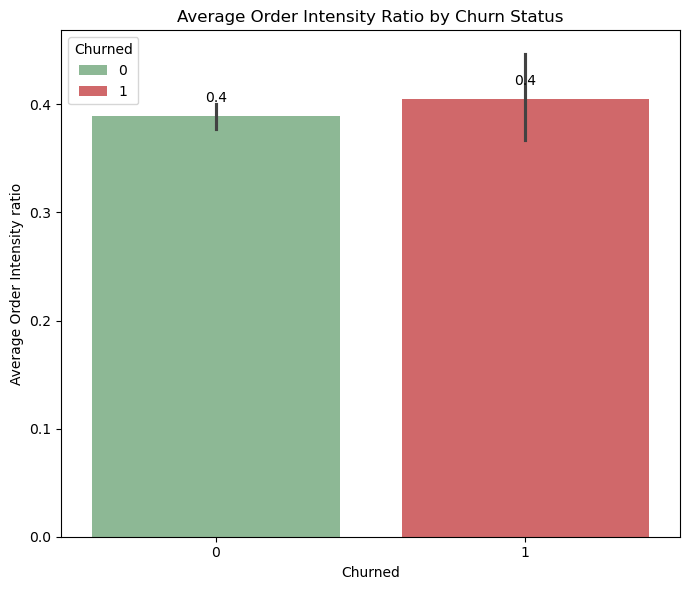

In [117]:
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="order_intensity_ratio", hue="Churned", data=df, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average Order Intensity ratio")
plt.title("Average Order Intensity Ratio by Churn Status")
plt.tight_layout()
plt.show()

In [119]:
df["recency_tenure_ratio"] = df["DaysSinceLastOrder"] / (df["MonthsActive"] * 30)

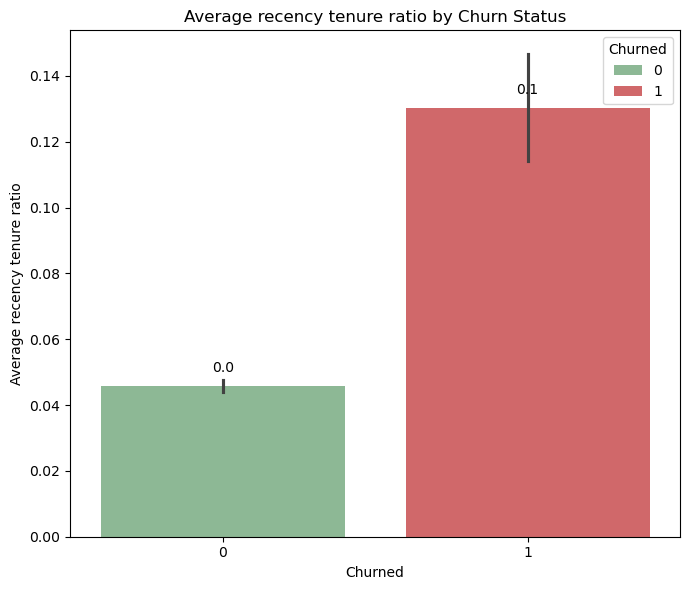

In [123]:
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="recency_tenure_ratio", hue="Churned", data=df, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average recency tenure ratio")
plt.title("Average recency tenure ratio by Churn Status")
plt.tight_layout()
plt.show()

In [129]:
df["spend_adjusted_activity"] = df["AvgOrderValue"] * df["NumOrdersLastQuarter"]

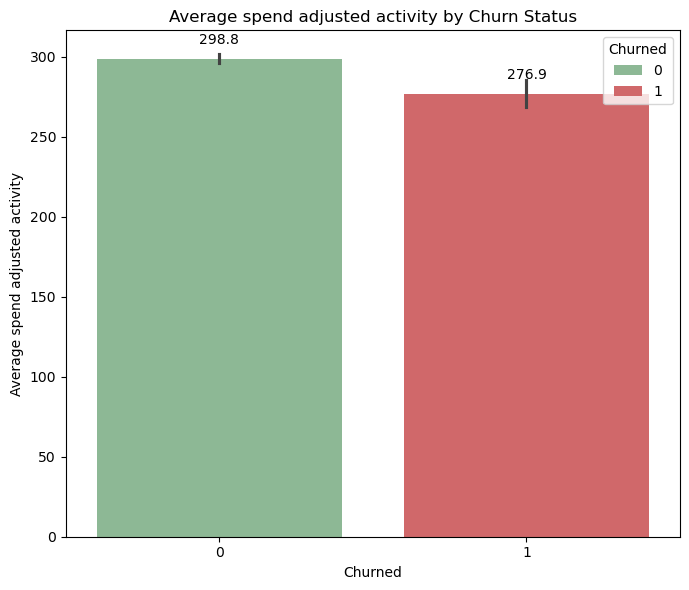

In [133]:
plt.figure(figsize=(7, 6))
# Assign the plot to an 'ax' variable to access its elements
ax = sns.barplot(x="Churned", y="spend_adjusted_activity", hue="Churned", data=df, palette=different_colors)
# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=8)

plt.xlabel("Churned")
plt.ylabel("Average spend adjusted activity")
plt.title("Average spend adjusted activity by Churn Status")
plt.tight_layout()
plt.show()

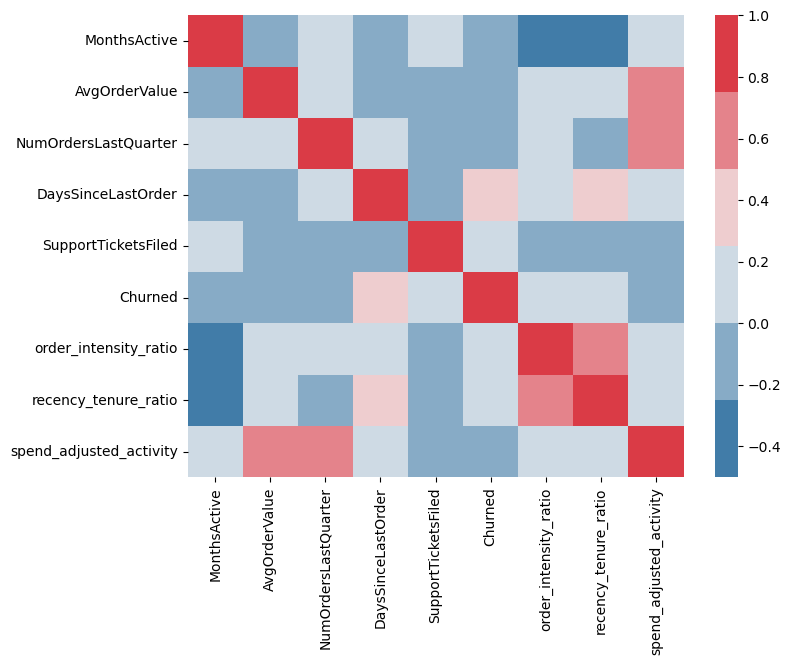

In [135]:
#correlation analysis
plt.figure(figsize=(8,6))
sns.heatmap(data=df.corr(),annot=False, cbar=True, cmap=sns.diverging_palette(240,10))
plt.show()

The `spend_adjusted_activity` and `order_intensity_ratio` features were not used because these features introduced multi-collinearity. The `recency_tenure_ratio` showed a slightly positive correlation with the target feature

## Baseline Model Development

In [216]:
target_y = raw_data["Churned"]
features_x = raw_data.drop(["Churned"], axis=1)

#### Build a baseline model using logistic regression

In [648]:
# Split dataset into train, validation, and test

# Split into Train (70%) and a temporary set (30%)
x_train_baseline, x_val_test_baseline, y_train_baseline, y_val_test_baseline = train_test_split(features_x, target_y, test_size=0.30, random_state=42)

# Split the val_test data (30%) evenly into Validation (15%) and Test (15%)
x_val_baseline, x_test_baseline, y_val_baseline, y_test_baseline = train_test_split(x_val_test_baseline, y_val_test_baseline, test_size=0.50, random_state=42)

print(f"shape of train data: {x_train_baseline.shape}", end="\n")
print(f"shape of validation data: {x_val_baseline.shape}", end="\n")
print(f"shape of test data: {x_test_baseline.shape}", end="\n")
print("="*30)
print(f"shape of train target: {y_train_baseline.shape}", end="\n")
print(f"shape of validation target: {y_val_baseline.shape}", end="\n")
print(f"shape of test target: {y_test.shape}")

shape of train data: (14000, 5)
shape of validation data: (3000, 5)
shape of test data: (3000, 5)
shape of train target: (14000,)
shape of validation target: (3000,)
shape of test target: (3000,)


In [650]:
baseline_model_pipeline = make_pipeline(RobustScaler(), LogisticRegression(max_iter=1000))
baseline_model_pipeline.fit(x_train_baseline, y_train_baseline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('robustscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a

In [652]:
baseline_pred = baseline_model_pipeline.predict(x_val_baseline)
print("--------------Classification Report----------------")
baseline_report = classification_report(y_val_baseline, baseline_pred)
print(baseline_report)

--------------Classification Report----------------
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      2758
           1       0.73      0.11      0.19       242

    accuracy                           0.93      3000
   macro avg       0.83      0.55      0.58      3000
weighted avg       0.91      0.93      0.90      3000



The result above shows that the baseline model is really good at identifying customers who won't churn but terrible at identifying customers who will.

`RobustScaler` is a better choice here than `StandardScaler` because it uses the median to scale your data, meaning it doesn't get distracted by weird spikes or extreme numbers.

### What metrics matter most for this problem?

There are several classification metrics to consider: Accuracy, Precision, Recall, F1-score, and PR-AUC.

**Accuracy answers, "How many predictions did the model get right overall?"**

`Accuracy = (TP + TN) / (TP + TN + FP + FN)`

In this use case, accuracy isn't a useful metric. Because the dataset has far more loyal customers than churned customers, a model can achieve a high accuracy score simply by learning to correctly identify loyal customers while doing poorly on the customers we actually care about: **the churners**. A model that predicts **not churned** for every single customer would still score ~93% accuracy while being completely useless to the retention team.

**Precision answers, "Of the customers the model flagged as likely to churn, how many actually churned?"**

`Precision = TP / (TP + FP)`

Precision matters when false alarms are costly. For example, if the retention strategy involved something expensive (a large discount) that you don't want to waste on customers who were never going to leave anyway.

**Recall answers: "Of all the customers who actually churned, how many did the model catch?"**

`Recall = TP / (TP + FN)`

A recall of 100% means the model found every churning customer, even if it also raised some false alarms along the way.

**F1-score** balances precision and recall into a single number. It only scores well when both precision and recall are reasonably good and drops if either one is weak.

---

The retention team's goal is to retain as many customers as possible, which means the cost of the two error types is asymmetric:

- **Missing a churning customer (false negative)** is expensive: the company loses that customer's revenue entirely, with no chance to intervene.
- **Misclassifying a loyal customer as churning (false positive)** is comparatively cheap: assuming the retention strategy is something like a limited-time discount or a check-in outreach, a loyal customer who's flagged incorrectly still stays and keeps generating revenue. The business just spends a little on an unnecessary incentive.

Because a false negative costs far more than a false positive in this context, **recall** is the more important metric for this use case. The priority is catching as many true churners as possible, even at the cost of some false alarms. This is also why precision, on its own, would be the wrong metric to optimize for here. A model can achieve high precision by only flagging the customers it's most confident about, which means it could miss a large share of churners (low recall) while still looking "precise." That's the opposite of what the retention team needs.

That said, optimizing for recall alone isn't ideal either. A model can trivially get 100% recall by flagging every customer to likely churn, which would overwhelm the team with false alarms and defeat the purpose of prioritization. This is why I'll use **PR-AUC** to evaluate and select between models, since it captures the precision–recall tradeoff across all thresholds rather than relying on a single cutoff.

---

### PR-AUC

PR-AUC (Precision-Recall Area Under the Curve) summarizes how well a model balances precision and recall **across every possible decision threshold**, not just the default 0.5 cutoff.

A model doesn't just output "churn" or "not churn"; it outputs a *probability* (e.g., "this customer has a 73% chance of churning"). You then pick a threshold to decide what counts as "predicted churn." If you set the threshold low (e.g., flag anyone above 10% probability), you'll catch almost every churner (high recall) but also flag a lot of loyal customers by mistake (low precision). If you set the threshold high (e.g., only flag customers above 90% probability), you'll be very confident about the customers you do flag (high precision) but will miss many actual churners (low recall).

The **precision-recall curve** plots precision against recall as you slide that threshold from low to high. **PR-AUC is the area under that curve** which is a single score summarizing how good that whole tradeoff is, from 0 to 1, where 1 is a perfect model.

Why PR-AUC over the more common ROC-AUC for this problem: ROC-AUC factors in true negatives (correctly identified loyal customers), and with ~92% of the dataset being loyal customers, a model can rack up a large number of true negatives almost for free and this inflates ROC-AUC making even a mediocre model look strong. PR-AUC ignores true negatives entirely and focuses only on how well the model finds and correctly identifies the *positive* (churn) class, which is exactly what matters here given the imbalance present in the dataset.

---

### Split data into train, val, and test to avoid data leakage during processing
----

In [548]:
data = raw_data.copy()

In [550]:
data.head()

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,DaysSinceLastOrder,SupportTicketsFiled,Churned
0,7,34.12,7,8,2,0
1,45,23.38,3,57,1,0
2,24,94.56,7,37,1,0
3,39,46.34,7,0,0,0
4,3,39.04,3,41,2,0


In [552]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MonthsActive          20000 non-null  int64  
 1   AvgOrderValue         20000 non-null  float64
 2   NumOrdersLastQuarter  20000 non-null  int64  
 3   DaysSinceLastOrder    20000 non-null  int64  
 4   SupportTicketsFiled   20000 non-null  int64  
 5   Churned               20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [554]:
y_target = data["Churned"]
x_features = data.drop(["Churned"], axis=1)

In [640]:
# Split dataset into train, validation, and test

# Split into Train (70%) and a temporary set (30%)
x_train, x_val_test, y_train, y_val_test = train_test_split(x_features, y_target, test_size=0.30, random_state=42)

# Split the val_test data (30%) evenly into Validation (15%) and Test (15%)
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.50, random_state=42)

print(f"shape of train data: {x_train.shape}", end="\n")
print(f"shape of validation data: {x_val.shape}", end="\n")
print(f"shape of test data: {x_test.shape}", end="\n")
print("="*30)
print(f"shape of train target: {y_train.shape}", end="\n")
print(f"shape of validation target: {y_val.shape}", end="\n")
print(f"shape of test target: {y_test_baseline.shape}")

shape of train data: (14000, 5)
shape of validation data: (3000, 5)
shape of test data: (3000, 5)
shape of train target: (14000,)
shape of validation target: (3000,)
shape of test target: (3000,)


### Feature Engineering

From the plot **recency_tenure_ratio** shows a better distinction between churned and loyal customers. A value closer to 0 shows the customers has been really active and placing orders while a value closer to 1 signifies that the customer have been quiet for some time which can be a signal that the customer might likely churn.

I will only not be including **order_intensity_ratio** because there's no significant difference between the two categories of customers.

In [642]:
x_train["recency_tenure_ratio"] = x_train["DaysSinceLastOrder"] / (x_train["MonthsActive"] * 30)
x_val["recency_tenure_ratio"] = x_val["DaysSinceLastOrder"] / (x_val["MonthsActive"] * 30)
x_test["recency_tenure_ratio"] = x_test["DaysSinceLastOrder"] / (x_test["MonthsActive"] * 30)

### Handling Class Imbalance

As seen in the classification report of the baseline logistic regression model, the class imbalance negatively affected the model's performance, particularly on the minority (churn) class.

To address this, there are two broad categories of approaches:

1. **Adjust how much importance the model assigns to each class** (class weighting), or
2. **Change the composition of the training data itself** by adding more churn records (oversampling) or removing loyal-customer records (undersampling).

For this problem, I'll be using option 1 rather than option 2.

**Why not option 2:**

Within option 2, you could use random oversampling or SMOTE.

- **Random oversampling** duplicates existing minority-class (churn) records until the classes are balanced. The problem is that the model isn't seeing any new information, just the same churn examples repeated multiple times. This risks the model memorizing those specific duplicated records rather than learning the general patterns that distinguish churners, which hurts its ability to generalize to new, unseen customers (overfitting).

- **SMOTE** (Synthetic Minority Oversampling Technique) instead generates new, synthetic minority-class records rather than duplicating existing ones. It picks a churn record, finds one of its nearest neighbors (also a churn record), and creates a new synthetic point somewhere along the line connecting the two in feature space. The risk here is that these synthetic points may not represent realistic customers. For example, if one churned customer has `AvgOrderValue = 50` and `DaysSinceLastOrder = 70`, and another has `AvgOrderValue = 100` and `DaysSinceLastOrder = 57`, SMOTE might generate a synthetic customer with `AvgOrderValue = 82` and `DaysSinceLastOrder = 65`, a data point that was never actually observed and may not reflect a real, plausible customer behavior pattern.

**Why option 1 instead:**

Class weighting avoids both of these issues because it doesn't alter the training data at all, the model still learns from real, observed customers only. Instead, it changes the *loss function* so that misclassifying a churn customer is penalized more heavily than misclassifying a loyal customer. This forces the model to pay closer attention to the minority class's patterns during training, rather than defaulting to the easy strategy of mostly predicting the majority class.

---


In [347]:
# Handling class imbalance manually
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train_baseline)
print(dict(zip([0, 1], weights)))

{0: 0.5415860735009671, 1: 6.511627906976744}


The class weights above show how much importance the model assigns to each class during training. When training the baseline model, `class_weight="balanced"` was used. While this improved recall for the churn class, it significantly reduced precision. Even though recall is the priority for this problem, a model that raises too many false alarms would overwhelm the retention team and undermine trust in the flagging system. The goal, therefore, is to find a class weight that keeps recall meaningfully higher than the baseline while preventing precision from dropping too far.

In [663]:
# Sweep a range of ratios: weight for class 1 (churn) relative to class 0 (loyal) = 1
ratios = np.arange(0.54, 12.5, 0.5) 

results = []

for ratio in ratios:
    weights = {0: 0.54, 1: ratio}
    model = LogisticRegression(class_weight=weights, max_iter=1000, random_state=42)
    model.fit(x_train, y_train)

    preds = model.predict(x_test)
    proba = model.predict_proba(x_test)[:, 1]

    results.append({
        "ratio": ratio,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "f2": fbeta_score(y_test, preds, beta=2),   # weighted 2x more than precision
        "pr_auc": average_precision_score(y_test, proba)
    })

results_df = pd.DataFrame(results)
results_df

,ratio,precision,recall,f1,f2,pr_auc
0,0.54,0.744186,0.128,0.218430,0.153404,0.371275
1,1.04,0.586207,0.204,0.302671,0.234591,0.371610
2,1.54,0.528169,0.300,0.382653,0.328371,0.371534
3,2.04,0.452632,0.344,0.390909,0.361345,0.371621
4,2.54,0.390152,0.412,0.400778,0.407437,0.371619
5,3.04,0.345133,0.468,0.397284,0.436893,0.371359
6,3.54,0.306533,0.488,0.376543,0.436338,0.371277
7,4.04,0.278132,0.524,0.363384,0.445275,0.371319
8,4.54,0.266541,0.564,0.362003,0.461086,0.371243
9,5.04,0.250000,0.584,0.350120,0.460859,0.371261


In [665]:
# Assumed a cost for losing a customer and missclassifying a loyal customer
cost_per_missed_churner = 500   
cost_per_false_alarm = 15       

n_actual_churn = y_test.sum()
n_actual_loyal = len(y_test) - n_actual_churn

results_df["FN"] = n_actual_churn * (1 - results_df["recall"])
results_df["TP"] = n_actual_churn * results_df["recall"]
results_df["FP"] = results_df["TP"] * (1 - results_df["precision"]) / results_df["precision"]

results_df["total_cost"] = (results_df["FN"] * cost_per_missed_churner) + \
                                (results_df["FP"] * cost_per_false_alarm)

results_df.sort_values("total_cost")

,ratio,precision,recall,f1,f2,pr_auc,FN,TP,FP,total_cost
23,12.04,0.140903,0.824,0.240654,0.418359,0.372190,44.0,206.0,1256.0,40840.0
22,11.54,0.145219,0.808,0.246191,0.422417,0.372240,48.0,202.0,1189.0,41835.0
21,11.04,0.149399,0.796,0.251580,0.426672,0.372192,51.0,199.0,1133.0,42495.0
20,10.54,0.153666,0.788,0.257180,0.431639,0.372200,53.0,197.0,1085.0,42775.0
19,10.04,0.159504,0.772,0.264384,0.436652,0.372197,57.0,193.0,1017.0,43755.0
18,9.54,0.164921,0.756,0.270774,0.440354,0.372268,61.0,189.0,957.0,44855.0
17,9.04,0.167598,0.720,0.271903,0.433944,0.372130,70.0,180.0,894.0,48410.0
16,8.54,0.175716,0.712,0.281869,0.442126,0.372090,72.0,178.0,835.0,48525.0
15,8.04,0.186243,0.704,0.294561,0.452442,0.372038,74.0,176.0,769.0,48535.0
14,7.54,0.189462,0.676,0.295972,0.446617,0.371956,81.0,169.0,723.0,51345.0


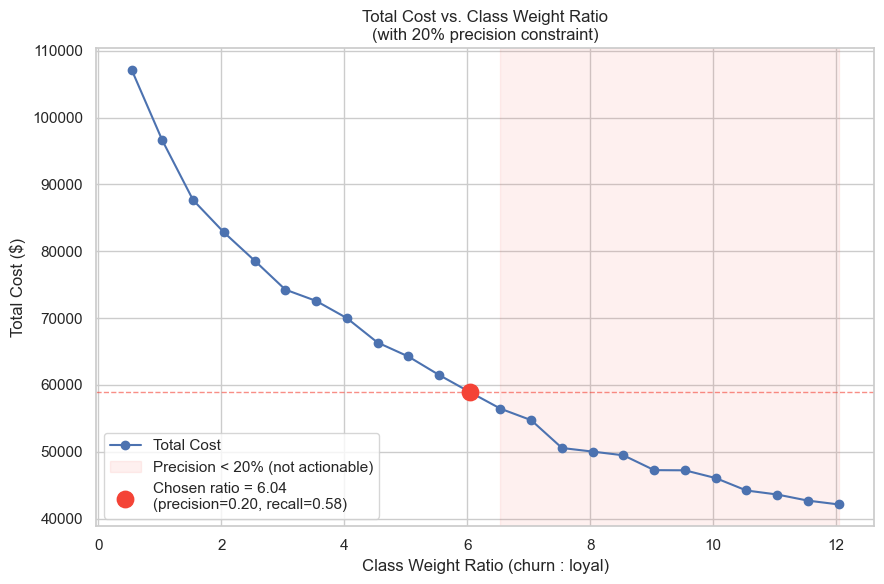

In [596]:
# Visualize total cost across ratios, with the precision constraint applied

precision_cap = 0.20
valid = results_df[results_df["precision"] >= precision_cap]
chosen = valid.loc[valid["total_cost"].idxmin()]

plt.figure(figsize=(9, 6))

# Full cost curve
plt.plot(results_df["ratio"], results_df["total_cost"], marker="o", color="#4C72B0", label="Total Cost")

# Shade the region where precision falls below what the team can handle
below_cap = results_df[results_df["precision"] < precision_cap]
if not below_cap.empty:
    plt.axvspan(below_cap["ratio"].min(), results_df["ratio"].max(),
                color="#F44336", alpha=0.08, label="Precision < 20% (not actionable)")

# Highlight the chosen operating point
plt.scatter(chosen["ratio"], chosen["total_cost"], color="#F44336", s=140, zorder=5,
            label=f"Chosen ratio = {chosen['ratio']:.2f}\n(precision={chosen['precision']:.2f}, recall={chosen['recall']:.2f})")

plt.axhline(chosen["total_cost"], color="#F44336", linestyle="--", linewidth=1, alpha=0.6)

plt.xlabel("Class Weight Ratio (churn : loyal)")
plt.ylabel("Total Cost ($)")
plt.title("Total Cost vs. Class Weight Ratio\n(with 20% precision constraint)")
plt.legend()
plt.tight_layout()
plt.show()

The model can be tuned to catch almost every customer who might churn, but the tradeoff is that it also flags a lot of loyal customers by mistake. If we tune purely for trying to catch everyone, most of the alerts the retention team gets would be false alarms.

For this problem, I assume that the retention team can only realistically act on alerts where **at least 1 in 5 (20%)** actually turn out to be real churn risks. Beyond that, the team would be spending time chasing customers who were never going to leave, and the flood of false alarms would make it harder to trust and act on the alerts at all.

So instead of picking the setting that looks best on paper, I am picking the best-performing option that still keeps false alarms at a rate the team can realistically handle while at the same time catching as many churning customers as possible.

### Model Development

In [516]:
# Logistic Regression with RobustScaler pipeline + selected class weight, evaluated across thresholds 0.3–0.7

chosen_ratio = chosen["ratio"] 
class_weights = {0: 0.54, 1: chosen_ratio}

log_reg_pipeline = make_pipeline(
    RobustScaler(),
    LogisticRegression(class_weight=class_weights, max_iter=1000, random_state=42)
)
log_reg_pipeline.fit(x_train, y_train)

val_proba = log_reg_pipeline.predict_proba(x_val)[:, 1]

thresholds = np.arange(0.3, 0.71, 0.05)
threshold_results = []

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_val, preds),
        "recall": recall_score(y_val, preds),
        "f2": fbeta_score(y_val, preds, beta=2)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f2
0,0.30,0.119464,0.847107,0.381893
1,0.35,0.138829,0.793388,0.408337
2,0.40,0.159236,0.723140,0.423319
3,0.45,0.183051,0.669421,0.437129
4,0.50,0.202006,0.582645,0.423169
5,0.55,0.225577,0.524793,0.414762
6,0.60,0.253968,0.462810,0.397445
7,0.65,0.303835,0.425620,0.394032
8,0.70,0.339623,0.371901,0.364964


In [446]:
# XGBoost with an equivalent class weight, evaluated across thresholds 0.3–0.7

xgb_scale_pos_weight = chosen_ratio / 0.54   # XGBoost expects weight relative to class 0 = 1

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=xgb_scale_pos_weight,
    eval_metric="logloss",
    n_estimators = 150,
    max_depth = 3, 
    learning_rate = 0.05,
    random_state=42
)
xgb_model.fit(x_train, y_train)

xgb_val_proba = xgb_model.predict_proba(x_val)[:, 1]

xgb_thresholds = np.arange(0.3, 0.71, 0.05)
xgb_threshold_results = []

for t in xgb_thresholds:
    xgb_preds = (xgb_val_proba >= t).astype(int)
    xgb_threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_val, xgb_preds),
        "recall": recall_score(y_val, xgb_preds),
        "f2": fbeta_score(y_val, xgb_preds, beta=2)
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)
xgb_threshold_df

,threshold,precision,recall,f2
0,0.30,0.124456,0.826446,0.388350
1,0.35,0.140392,0.739669,0.399019
2,0.40,0.156015,0.685950,0.408465
3,0.45,0.174312,0.628099,0.413043
4,0.50,0.200861,0.578512,0.420420
5,0.55,0.225131,0.533058,0.418559
6,0.60,0.250000,0.454545,0.390625
7,0.65,0.308442,0.392562,0.372257
8,0.70,0.336066,0.338843,0.338284


**Insights**

The class weight for the Logistic Regression model was tuned to control how much importance the model assigns to each class, helping address the severe class imbalance in the churn data.
Two models, Logistic Regression and XGBoost, were compared. Logistic Regression delivered the better performance, achieving higher recall at a precision cap of 20%.
Business costs were assumed for each type of error: `$500` for a missed churner (false negative) and `$15` for misclassifying a loyal customer (false positive). 

Calculating total cost across different thresholds showed that prioritizing precision over recall increased the overall cost to the business, since missed churners are far more expensive than false alarms.
Based on this, a 20% precision cap was set as the threshold the retention team can realistically act on, and recall was optimized within that constraint to minimize total business cost while keeping the volume of false alarms manageable.

In [654]:
### Logistic Regression

# Final Logistic Regression model trained with selected class weight, evaluated at threshold = 0.5

final_log_reg = make_pipeline(
    RobustScaler(),
    LogisticRegression(class_weight=class_weights, max_iter=1000, random_state=42)
)
final_log_reg.fit(x_train, y_train)

final_threshold = 0.5

# Validation set 
val_proba = final_log_reg.predict_proba(x_val)[:, 1]
val_preds = (val_proba >= final_threshold).astype(int)

print("--------------Validation Classification Report----------------")
print(classification_report(y_val, val_preds))
print("fbeta-score: ", fbeta_score(y_val, val_preds, beta=2))

--------------Validation Classification Report----------------
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      2758
           1       0.20      0.58      0.30       242

    accuracy                           0.78      3000
   macro avg       0.58      0.69      0.58      3000
weighted avg       0.90      0.78      0.82      3000

fbeta-score:  0.4221556886227545


In [656]:
# Test set
test_proba = final_log_reg.predict_proba(x_test)[:, 1]
test_preds = (test_proba >= final_threshold).astype(int)

print("\n--------------Test Classification Report----------------")
print(classification_report(y_test, test_preds))
print("fbeta-score: ", fbeta_score(y_test, test_preds, beta=2))


--------------Test Classification Report----------------
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      2750
           1       0.22      0.61      0.32       250

    accuracy                           0.79      3000
   macro avg       0.59      0.71      0.60      3000
weighted avg       0.90      0.79      0.83      3000

fbeta-score:  0.44837758112094395


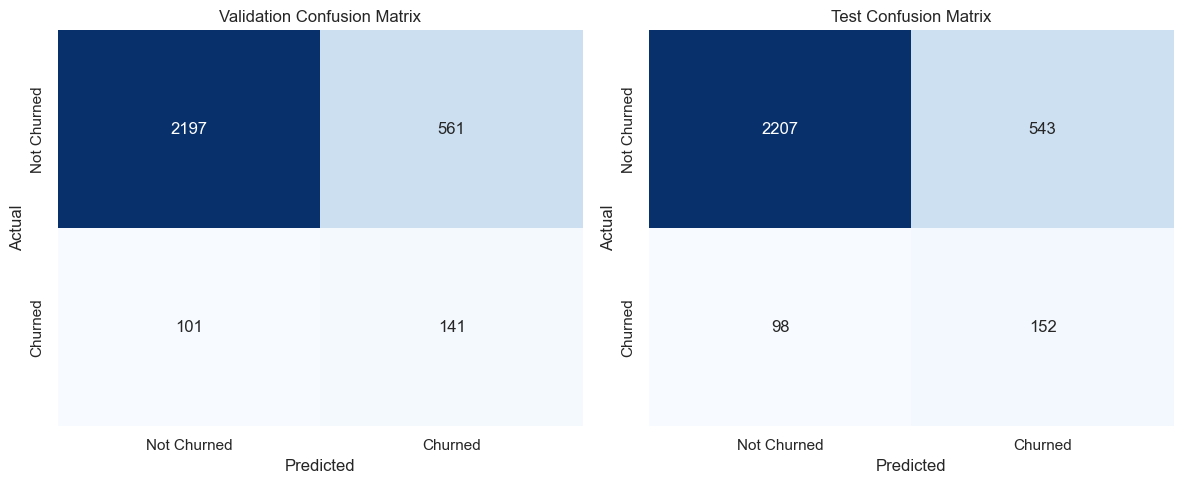

In [482]:
# Visualize confusion matrices for validation and test sets

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

val_cm = confusion_matrix(y_val, val_preds)
sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"], ax=axes[0])
axes[0].set_title("Validation Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

test_cm = confusion_matrix(y_test, test_preds)
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"], ax=axes[1])
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

                Feature  Coefficient
0   SupportTicketsFiled     0.595366
1  recency_tenure_ratio     0.480484
2    DaysSinceLastOrder     0.480484
3          MonthsActive    -0.257779
4  NumOrdersLastQuarter    -0.216345
5         AvgOrderValue    -0.054735


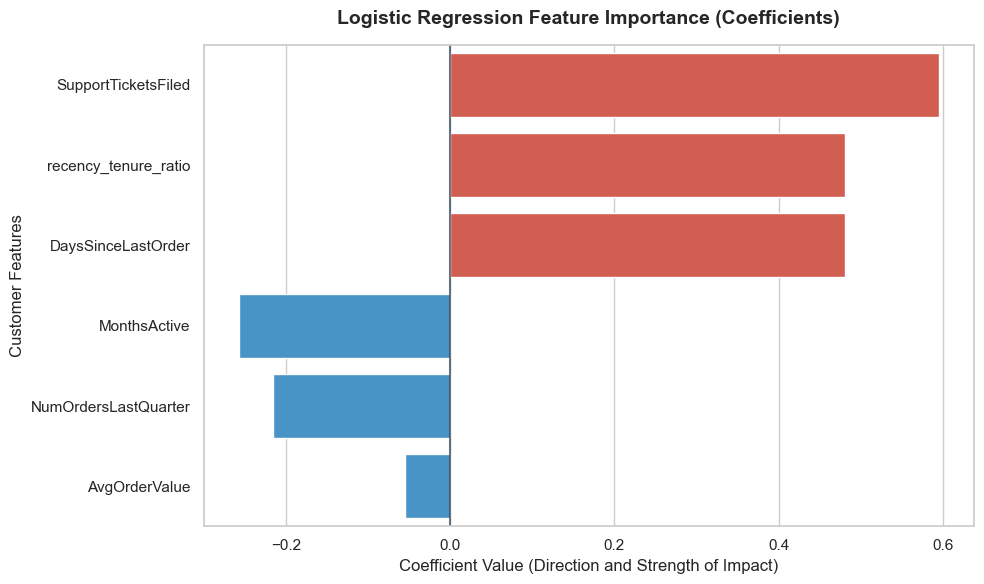

In [594]:
# Visualize the importance of the features
log_reg_model = log_reg_pipeline.named_steps['logisticregression']

coefficients = log_reg_model.coef_[0]
feature_importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': coefficients,
    'Absolute_Value': abs(coefficients) 
})

feature_importance_df = feature_importance_df.sort_values(by='Absolute_Value', ascending=False).reset_index(drop=True)

print(feature_importance_df[['Feature', 'Coefficient']])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colors = ['#e74c3c' if c > 0 else '#3498db' for c in feature_importance_df['Coefficient']]

sns.barplot(data=feature_importance_df,x='Coefficient',y='Feature', hue='Feature',palette=colors)

plt.axvline(x=0, color='#2c3e50', linestyle='-', alpha=0.7, linewidth=1.5)
plt.title("Logistic Regression Feature Importance (Coefficients)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Coefficient Value (Direction and Strength of Impact)", fontsize=12)
plt.ylabel("Customer Features", fontsize=12)
plt.tight_layout()
plt.show()

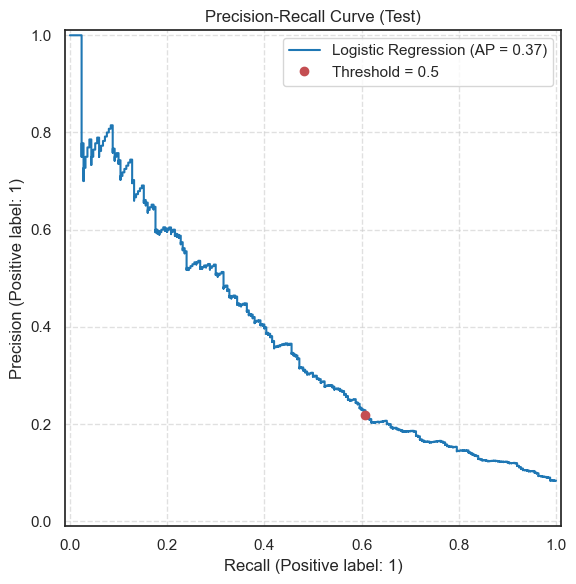

In [618]:
# Plot Precision-Recall curve
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(
    final_log_reg, 
    x_test, 
    y_test, 
    ax=ax, 
    name="Logistic Regression",
    color="#1f77b4"
)

# Highlight specific threshold (0.5) point on the curve
test_proba = final_log_reg.predict_proba(x_test)[:, 1]
from sklearn.metrics import precision_score, recall_score
p = precision_score(y_test, test_proba >= 0.5)
r = recall_score(y_test, test_proba >= 0.5)

plt.plot(r, p, 'ro', label='Threshold = 0.5')
plt.title("Precision-Recall Curve (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## Results

The model catches roughly 6 out of 10 customers who are about to churn in exchange for flagging some loyal customers who weren't actually leaving. This trade-off was a deliberate choice; it reflects that missing a churner costs far more than a wasted retention outreach.

### Validation vs. Test Performance

| Metric (churn class) | Validation | Test |
|---|---|---|
| Precision | 20% | 22% |
| Recall | 58% | 61% |
| Fbeta-score | 0.42 | 0.45 |
| Overall accuracy | 78% | 79% |

Test performance is in line with (actually slightly better than) validation, which means the model isn't overfitting to the validation set.

Out of every 3,000 customers scored:
- **~250 actually churn.** The model correctly flags **~152 of them (61%)** on the test set.
- It misses **~98 churners,** which are the costly errors, since a missed churner is lost revenue with no chance to intervene.
- To catch those 150, it also flags **~550 loyal customers** who weren't going to leave. However, this is still within the limit of what the team could handle.

So for roughly every 1 correct churn flag, there are about 3-4 false alarms. That's the result of the deliberate 20% precision floor set: below that, the flood of false positives would overwhelm the team and erode trust in the alerts, and above it, a lot of churned customers will slip through.

Under the assumption that losing a customer is more expensive than misclassifying a loyal one, optimizing for accuracy or precision would actually cost UrbanCart *more* money, because it lets expensive churners go undetected to avoid annoying loyal customers with cheap false alarms. The model was tuned (via class weighting + threshold selection) specifically to minimize total dollar cost under that assumption, not to maximize any single metric.

---
Now, this model's metrics could be better; however, its current state might be due to the low number of features, which explains why XGBoost performed slightly worse than logistic regression.


In [658]:
import joblib
joblib.dump(final_log_reg, "churn_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


# Customer Churn Early-Warning Model — UrbanCart

## 1. The Problem

The Retention Team noticed that customers were **going quiet** and leaving without any warning. By the time monthly reports showed a customer as churned, it was already too late to do anything about it.

My Job as the ML Engineer was to build something that flags at-risk customers *before* they fully leave, using data UrbanCart already collects on every account.

---
Try out the app here: https://urbancart-customer-churn.streamlit.app/

Check the interactive dashboard here: https://obinna-muonanu.github.io/TeSA-AI-Specialization-Assignment-III/

## 2. The Data

I was given records for about 20,000 customers, with five pieces of information tracked for each one:

- **MonthsActive** – how long they've been a customer
- **AvgOrderValue** – how much they typically spend per order
- **NumOrdersLastQuarter** – how many orders they placed recently
- **DaysSinceLastOrder** – how long it's been since their last order
- **SupportTicketsFiled** – how many support complaints they've filed
- **Churned** – whether they actually stopped ordering (this is the target feature)

**Important fact about the data:** only about 8% of customers in the dataset actually churned. The other 92% are loyal customers. This imbalance turned out to be the single most important thing to design around.

---
![alt text](image.png)

## 3. Why "How Often Is the Model Right?" Is the Wrong Question

The most obvious way to grade a model is accuracy, how many predictions did it get right overall? For this problem, that measure is misleading and would actually hide a badly broken model.

Since 92% of customers don't churn, a model could simply guess **this customer will NOT churn** for every single person, get it right 92% of the time, and look excellent on paper, while being completely useless. It would never catch a single at-risk customer, which is the entire point of this project.

Because of this, I did not use overall accuracy to judge success. Instead, I used metrics that specifically measure how well the model finds the churners.

## 4. What Was Measured Instead, and Why

I looked at two mistakes a model can make, and treated them very differently:

- **Missing a churner (false negative):** the model says a customer is fine, but they actually leave. This is expensive as that customer's future revenue is gone, and there was no chance to step in.
- **Wrongly flagging a loyal customer (false alarm / false positive):** the model says a customer is at risk, but they were never planning to leave. This is cheap by comparison, worst case scenario, the team sends them an unnecessary discount or check-in message.

Because missing a real churner costs far more than a false alarm, I deliberately built the model to **prioritize catching churners (recall)**, even if that means accepting a fair number of false alarms along the way. I also set a limit that the retention team can only realistically act on alerts if at least 1 in 5 (20%) turn out to be real, otherwise the alerts become noise nobody trusts. Every tuning decision respected that 20% floor.

## 5. What I Found in the Data

Before building any model, I looked at what actually separates customers who churn from those who don't:

- **Only one signal stood out clearly:** how long it's been since a customer's last order. Customers who eventually churned had, on average, gone noticeably longer without ordering.
- **The other four features on their own barely mattered.** How long someone has been a customer, how much they typically spend, how many orders they placed recently, and how many support tickets they filed all looked nearly identical between churners and loyal customers.

This finding is useful because it tells the retention team that "long-time customer," "big spender," and "recent order volume" are **not** reliable warning signs by themselves. Recency of ordering is.

## 6. Models Built

I built and compared two different models:

1. **Logistic Regression** — a simple, transparent model, adjusted so it pays much more attention to churn cases despite them being rare in the data.
2. **XGBoost** — a more complex, tree-based model, tuned the same way for fairness of comparison.

Both models were trained only on a training portion of the data, then checked against a separate validation set (used for evaluating tuning) and a completely untouched test set (used for the final report). This keeps the evaluation honest and the model is never graded on data it already learned from.

**Result:** Logistic Regression performed better for this problem. It caught more churners at the same false-alarm rate the team can tolerate. So it is the recommended model. XGBoost was not far off, its under-performance might be due to the small feature set in the data

## 7. Final Results

Numbers below are for identifying customers who churn, on data the model had never seen before (the test set):

| Metric | Meaning in plain terms | Result |
|---|---|---|
| Precision | Of the customers flagged as at-risk, how many really were | 22% |
| Recall | Of the customers who actually churned, how many the model caught | 61% |
| Overall accuracy | (Not the right measure here, just included only for reference) | 79% |

In practical terms: out of every 250 customers who actually churn, the model correctly flags around 150 of them. To do that, it also flags roughly 550 loyal customers out of 2,750 as a false alarm. That trade-off was deliberate as it reflects that catching real churners is worth some extra, low-cost false alarms.

## 8. Recommendation

I recommend using the **Logistic Regression model** as the churn early-warning system, with alerts sent to the retention team whenever a customer's risk score crosses the chosen threshold.

## 9. Limitations and What to Watch

- The costs used to guide these decisions (`$500` assumed loss per missed churner, `$15` assumed cost per false alarm) were **assumed estimates for this problem**.
- The model relies heavily on one signal (days since last order). If UrbanCart's business changes, for example, customers naturally order less often for a legitimate reason. This model should be re-checked, since its main signal could become less reliable.
- This model flags risk; it does not explain *why* a specific customer is at risk. Pairing it with the retention team's judgment is still important.

---